# Dwarf Example 19: Omega vs Distance — Selection Effect Check

**EPS Research — Dwarf/Irregular HI Corpus v1.0**

Does omega correlate with distance? If so, it could indicate
a resolution-dependent selection effect rather than physics.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20320362  
**Sources:** LVHIS (Koribalski 2019), VLA-ANGST (Ott 2012), LITTLE THINGS (Oh 2015), WALLABY DR2  
**Dependencies:** Python 3, numpy, matplotlib

r(omega, distance) = -0.180
Interpretation: no strong selection effect


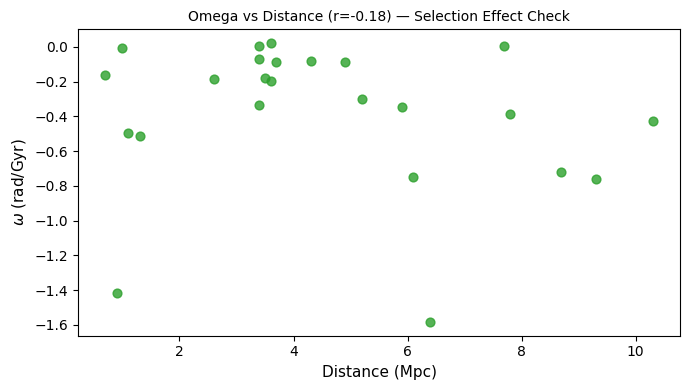

In [1]:
import json, csv, numpy as np, matplotlib.pyplot as plt
with open('dwarf_irregular_corpus_v1.json') as f:
    corpus=json.load(f)
csv_rows={}
with open('dwarf_irregular_corpus_v1_flat.csv') as f:
    for r in csv.DictReader(f): csv_rows[r['galaxy']]=r
results=[]
for g in corpus['galaxies']:
    if not g.get('omega_ready') or not g.get('data') or len(g['data'])<2: continue
    d=g['data']; R=[p['Rad'] for p in d]; V=[p.get('Vrot', 0) for p in d]
    R1,V1=R[0],V[0]; R2,V2=R[-1],V[-1]
    if R1>0 and R2>0 and V1>0 and V2>0:
        omega=(V2/R2-V1/R1)*(R1/R2)**1.5
        results.append({'omega':omega,'dist':float(g['distance_mpc'])})
dists=[r['dist'] for r in results]; omegas=[r['omega'] for r in results]
corr=np.corrcoef(dists,omegas)[0,1]
print(f"r(omega, distance) = {corr:.3f}")
print(f"Interpretation: {'selection effect possible' if abs(corr)>0.3 else 'no strong selection effect'}")
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(dists,omegas,s=40,color='#2ca02c',alpha=0.8)
ax.set_xlabel('Distance (Mpc)',fontsize=11); ax.set_ylabel(r'$\omega$ (rad/Gyr)',fontsize=11)
ax.set_title(f'Omega vs Distance (r={corr:.2f}) — Selection Effect Check',fontsize=10)
plt.tight_layout(); plt.savefig('dw19_omega_distance.png',dpi=150,bbox_inches='tight'); plt.show()